# BCI Data Analysis: Concentrate vs Relax States

This notebook performs statistical analysis and visualization on the EEG features collected during the calibration process. Our goal is to evaluate the differences between the 'concentrate' and 'relax' brain states and determine a threshold for the attention level.

## 1. Preparation
Importing necessary libraries and loading the dataset.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# --- SPECIFY YOUR FILES HERE ---
concentrate_file = 'calibration_20260512_2300.csv' # Change to your concentrate trial file
relax_file = 'calibration_20260512_2254.csv'       # Change to your relax trial file

if os.path.exists(concentrate_file) and os.path.exists(relax_file):
    # Load and ensure labels are correct
    df_con = pd.read_csv(concentrate_file)
    df_con['trial_label'] = 'concentrate'
    
    df_rel = pd.read_csv(relax_file)
    df_rel['trial_label'] = 'relax'
    
    # Combine datasets
    df = pd.concat([df_con, df_rel], ignore_index=True)
    print(f"Successfully loaded datasets.")
    print(f"- Concentrate: {len(df_con)} samples")
    print(f"- Relax: {len(df_rel)} samples")
    display(df.head())
else:
    print("Error: One or both files were not found. Please check the filenames.")

Successfully loaded datasets.
- Concentrate: 87 samples
- Relax: 450 samples


,timestamp,trial_label,ch1_theta,ch1_alpha,ch1_beta,ch1_gamma,ch2_theta,ch2_alpha,ch2_beta,ch2_gamma,...,ch7_theta,ch7_alpha,ch7_beta,ch7_gamma,ch8_theta,ch8_alpha,ch8_beta,ch8_gamma,avg_beta_alpha,avg_engagement_index
0,23:00:01.738,concentrate,4422682.419,1614982.580,1609407.536,331855.781,225115.560,83307.098,82972.178,17197.148,...,16163.261,5448.861,5567.726,1194.106,1293410.016,472646.743,471394.240,96663.644,1.0010,0.2658
1,23:00:01.871,concentrate,4422682.419,1614982.580,1609407.536,331855.781,225115.560,83307.098,82972.178,17197.148,...,16163.261,5448.861,5567.726,1194.106,1293410.016,472646.743,471394.240,96663.644,1.0010,0.2658
2,23:00:01.996,concentrate,4428830.169,1605177.136,1606838.638,331239.803,227276.953,81997.396,82954.790,17093.328,...,15471.100,5615.057,5569.415,1196.887,1304265.280,472014.570,472832.516,96725.863,1.0016,0.2662
3,23:00:02.133,concentrate,4428830.169,1605177.136,1606838.638,331239.803,227276.953,81997.396,82954.790,17093.328,...,15471.100,5615.057,5569.415,1196.887,1304265.280,472014.570,472832.516,96725.863,1.0016,0.2662
4,23:00:02.265,concentrate,4428830.169,1605177.136,1606838.638,331239.803,227276.953,81997.396,82954.790,17093.328,...,15471.100,5615.057,5569.415,1196.887,1304265.280,472014.570,472832.516,96725.863,1.0016,0.2662


## 2. Descriptive Statistics
Comparing the Mean and Standard Deviation (SD) for the Engagement Index and specific brainwave bands.

In [6]:
# Group by trial label
stats_summary = df.groupby('trial_label')['avg_engagement_index'].agg(['mean', 'std', 'var', 'count']).reset_index()
print("Engagement Index Statistics:")
display(stats_summary)

# Calculate Global averages for bands (averaging across all channels)
df['global_theta'] = df[[col for col in df.columns if 'theta' in col]].mean(axis=1)
df['global_alpha'] = df[[col for col in df.columns if 'alpha' in col and 'beta_alpha' not in col]].mean(axis=1)
df['global_beta'] = df[[col for col in df.columns if 'beta' in col and 'beta_alpha' not in col]].mean(axis=1)
df['global_gamma'] = df[[col for col in df.columns if 'gamma' in col]].mean(axis=1)

band_stats = df.groupby('trial_label')[['global_theta', 'global_alpha', 'global_beta', 'global_gamma']].mean().reset_index()
print("\nGlobal Band Power Mean Comparison:")
display(band_stats)

Engagement Index Statistics:


,trial_label,mean,std,var,count
0,concentrate,0.239156,0.043980,0.001934,87
1,relax,0.291110,0.060558,0.003667,450



Global Band Power Mean Comparison:


,trial_label,global_theta,global_alpha,global_beta,global_gamma
0,concentrate,4.205000e+07,1.174890e+07,6.096632e+06,572408.988766
1,relax,9.242149e+06,4.912261e+06,4.224458e+06,572879.408479


## 3. Statistical Analysis (ANOVA)
We use One-Way ANOVA to test if the differences in Engagement Index between states are statistically significant ($p < 0.05$).

In [7]:
states = df['trial_label'].unique()
data_groups = [df[df['trial_label'] == state]['avg_engagement_index'] for state in states]

f_stat, p_val = stats.f_oneway(*data_groups)
print(f"ANOVA Result for Engagement Index:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nRESULT: There is a statistically significant difference between brain states.")
else:
    print("\nRESULT: No significant difference found. Consider refining the protocol or increasing sample size.")

ANOVA Result for Engagement Index:
F-statistic: 58.0719
P-value: 1.1571e-13

RESULT: There is a statistically significant difference between brain states.


## 4. Visualizations
Visualizing the data distribution to understand the clear separation between states.

C:\Users\Hathairat Srighiwong\AppData\Local\Temp\ipykernel_20976\447866078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trial_label', y='avg_engagement_index', data=df, ax=axes[0], palette="Set2")


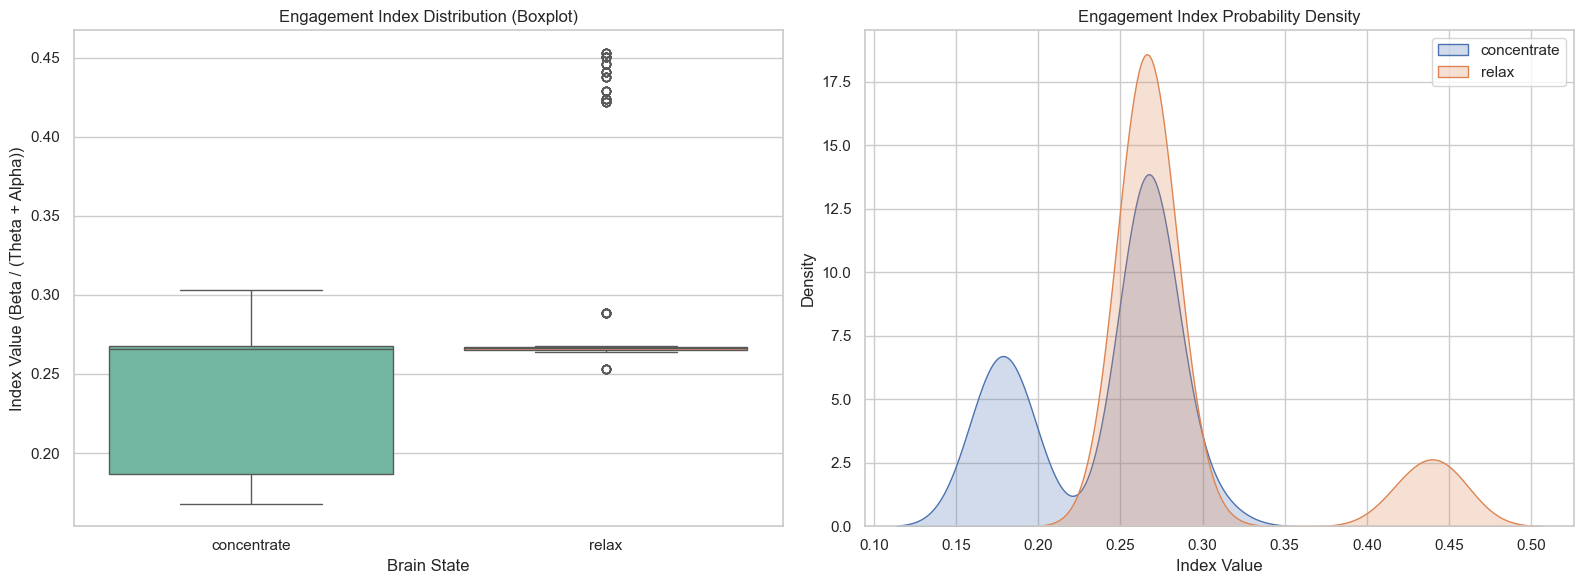

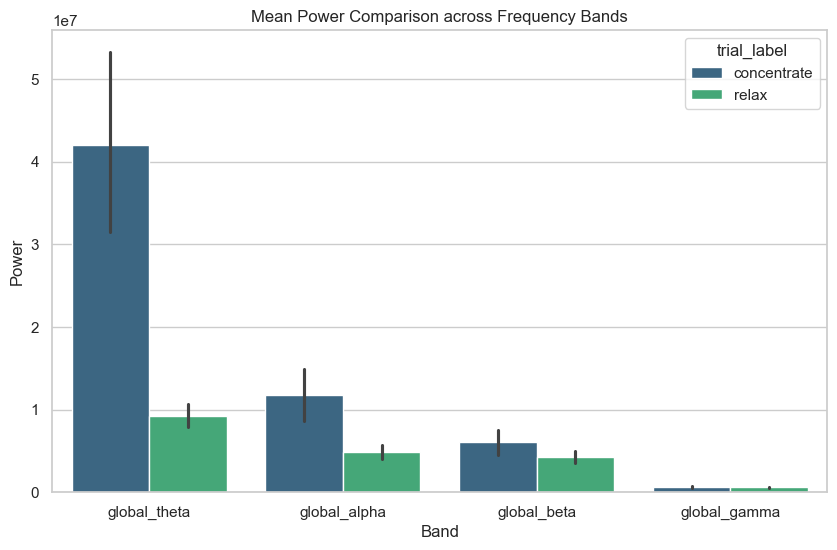

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot of Engagement Index
sns.boxplot(x='trial_label', y='avg_engagement_index', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Engagement Index Distribution (Boxplot)')
axes[0].set_xlabel('Brain State')
axes[0].set_ylabel('Index Value (Beta / (Theta + Alpha))')

# 2. KDE Plot of Engagement Index
for state in states:
    sns.kdeplot(df[df['trial_label'] == state]['avg_engagement_index'], label=state, fill=True, ax=axes[1])
axes[1].set_title('Engagement Index Probability Density')
axes[1].set_xlabel('Index Value')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Brainwave Band Comparison (Radar-like Bar Chart)
melted_df = df.melt(id_vars=['trial_label'], value_vars=['global_theta', 'global_alpha', 'global_beta', 'global_gamma'], 
                   var_name='Band', value_name='Power')

plt.figure(figsize=(10, 6))
sns.barplot(x='Band', y='Power', hue='trial_label', data=melted_df, palette="viridis")
plt.title('Mean Power Comparison across Frequency Bands')
plt.show()

## 5. Threshold Determination
Determining the criterion for 'High Attention' based on the Relax state distribution.

--- Proposed Attention Thresholds ---
Mean Relax Index: 0.2911
Mean Concentrate Index: 0.2392

1. Standard Threshold (Relax Mean + 1SD): 0.3517
2. Midpoint Threshold: 0.2651


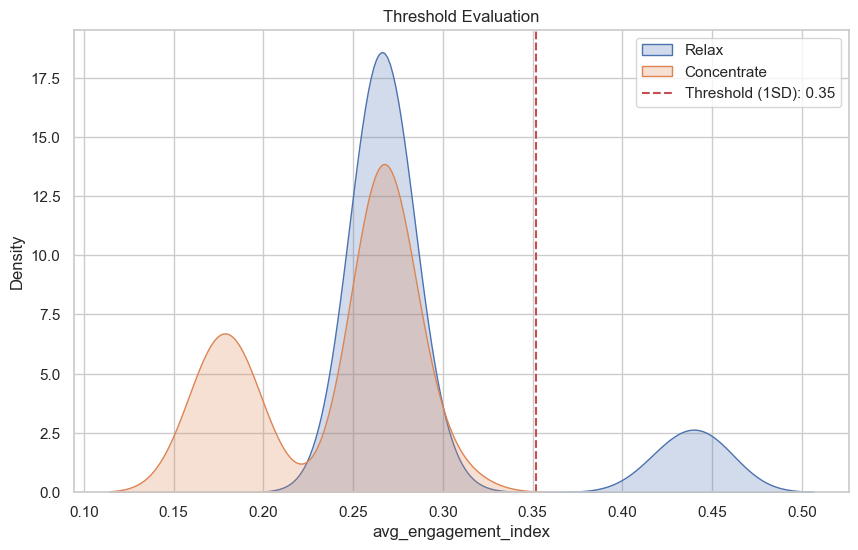

In [9]:
relax_data = df[df['trial_label'] == 'relax']['avg_engagement_index']
concentrate_data = df[df['trial_label'] == 'concentrate']['avg_engagement_index']

if len(relax_data) > 0 and len(concentrate_data) > 0:
    # Heuristic: Mean of Relax + 1 Standard Deviation
    threshold_1sd = relax_data.mean() + relax_data.std()
    # Heuristic: Midpoint between means
    midpoint = (relax_data.mean() + concentrate_data.mean()) / 2
    
    print(f"--- Proposed Attention Thresholds ---")
    print(f"Mean Relax Index: {relax_data.mean():.4f}")
    print(f"Mean Concentrate Index: {concentrate_data.mean():.4f}")
    print(f"\n1. Standard Threshold (Relax Mean + 1SD): {threshold_1sd:.4f}")
    print(f"2. Midpoint Threshold: {midpoint:.4f}")
    
    # Visualize threshold on the distribution
    plt.figure(figsize=(10, 6))
    sns.kdeplot(relax_data, label='Relax', fill=True)
    sns.kdeplot(concentrate_data, label='Concentrate', fill=True)
    plt.axvline(threshold_1sd, color='r', linestyle='--', label=f'Threshold (1SD): {threshold_1sd:.2f}')
    plt.title('Threshold Evaluation')
    plt.legend()
    plt.show()
else:
    print("Error: Data for one or both states is missing from the CSV.")